In [2]:
%run ./r_model_data_loader.ipynb

Test shape: (685159, 191)
Weeks: 44 - 91 (48 unieke weken)
Default rate: 0.0335 (22955 positieven)
LR : C=0.000195172, l1_ratio=0.0, n_features=191
XGB: n_trees=450, n_features=191
MLP: hidden=[128], n_features=191
Device: cpu


c:\Users\Vik\Documents\UGent\Masterproef\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
import numpy as np

# Results - Data drift detection

De frozen-model opzet (train op week 0-43, evalueren op week 44-91 zonder herfitten)
is alleen zinvol als er ook echt iets verschuift tussen train- en testperiode. Dat tonen
we op twee onafhankelijke assen:

1. **Label-kant** — de default rate per week.
2. **Input-kant** — PSI per feature per week ten opzichte van de bevroren trainverdeling.

*Scope-beperking:* concept drift (verandering in de relatie tussen features en target)
meten we bewust niet. Dat vraagt herfitten op testdata en breekt daarmee precies het
frozen-model design dat we hier onderzoeken.

In [4]:
import gc
import matplotlib.pyplot as plt

LAST_TRAIN_WEEK = 43        # zie m2_data_preparation.ipynb: CUTOFF_WEEK = 43
COVID_DATE = pd.Timestamp("2020-03-11")

N_BINS = 10
PSI_EPS = 1e-4              # voorkomt log(0) bij lege bins
PSI_ALERT = 0.25            # gangbare drempel voor een significante shift op featureniveau
NULL_WEEKS = [43, 91]       # laatste trainweek + laatste (en kleinste) testweek
NULL_REPEATS = 20

# WEEK_NUM -> startdatum, zodat de COVID-cutoff uit de datum volgt en niet als
# magisch weeknummer in de code staat.
base = pd.read_parquet(f"{DATA_DIR}/train/train_base.parquet",
                       columns=["case_id", "date_decision", "WEEK_NUM"])
base["date_decision"] = pd.to_datetime(base["date_decision"])
week_start = base.groupby("WEEK_NUM")["date_decision"].min()
COVID_WEEK = int(week_start[week_start <= COVID_DATE].index.max())
del base
gc.collect()

print(f"Laatste trainweek : {LAST_TRAIN_WEEK} "
      f"({week_start[LAST_TRAIN_WEEK].date()} - {week_start[LAST_TRAIN_WEEK + 1].date()})")
print(f"COVID-cutoff      : {COVID_DATE.date()} valt in week {COVID_WEEK} "
      f"(start {week_start[COVID_WEEK].date()})")
print(f"Laatste week      : {int(week_start.index.max())} "
      f"(start {week_start.loc[week_start.index.max()].date()})")

Laatste trainweek : 43 (2019-10-29 - 2019-11-05)
COVID-cutoff      : 2020-03-11 valt in week 62 (start 2020-03-10)
Laatste week      : 91 (start 2020-09-29)


### Label-kant: default rate per week

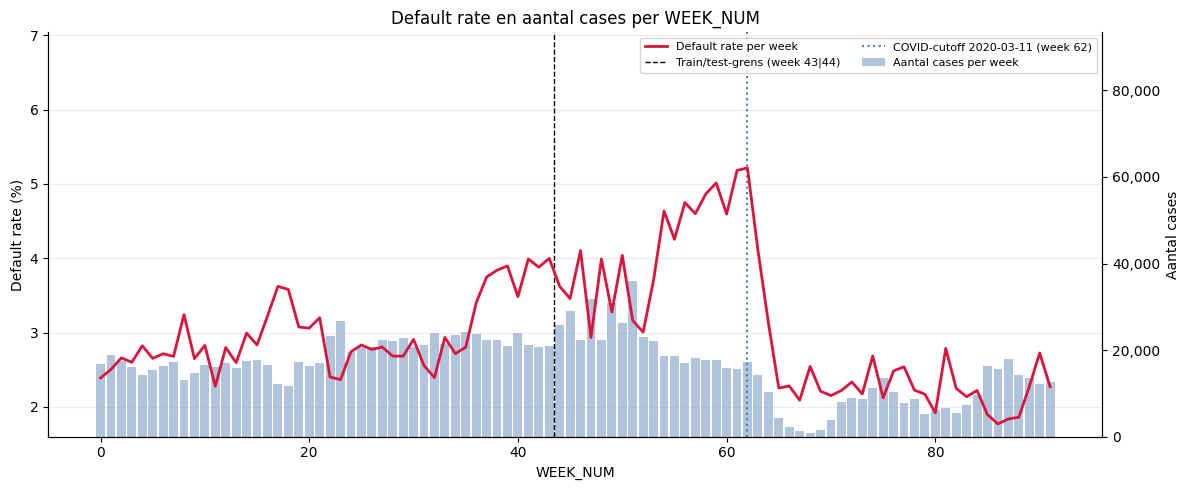

Default rate pre-COVID  (week < 62) : 0.0329
Default rate vanaf COVID (week >= 62): 0.0243


In [ ]:
# Train-target erbij zodat de reeks over de volledige periode loopt (week 0-91) en de
# breuk op de train/test-grens zichtbaar blijft.
train_target = pd.read_parquet(f"{DATA_DIR}/df_train_preprocessed_cutoff44.parquet",
                               columns=["WEEK_NUM", "target"])
test_target = pd.DataFrame({"WEEK_NUM": week_num_test, "target": y_test})

weekly = (
    pd.concat([train_target, test_target])
    .groupby("WEEK_NUM")["target"]
    .agg(default_rate="mean", n="count")
    .reset_index()
)
del train_target, test_target
gc.collect()

pre_covid_rate = weekly.loc[weekly["WEEK_NUM"] < COVID_WEEK, "default_rate"].mean()
post_covid_rate = weekly.loc[weekly["WEEK_NUM"] >= COVID_WEEK, "default_rate"].mean()

fig, ax_rate = plt.subplots(figsize=(12, 5))
ax_n = ax_rate.twinx()

ax_n.bar(weekly["WEEK_NUM"], weekly["n"], color="lightsteelblue", width=0.85,
         label="Aantal cases per week", zorder=1)
ax_n.set_ylabel("Aantal cases")
ax_n.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{int(y):,}"))
ax_n.set_ylim(top=weekly["n"].max() * 2.6)  # houdt de balken laag zodat de lijn goed zichtbaar blijft

ax_rate.plot(weekly["WEEK_NUM"], weekly["default_rate"] * 100,
             color="crimson", linewidth=2, label="Default rate per week", zorder=3)
ax_rate.axvline(LAST_TRAIN_WEEK + 0.5, color="black", linestyle="--", linewidth=1,
                label=f"Train/test-grens (week {LAST_TRAIN_WEEK}|{LAST_TRAIN_WEEK + 1})",
                zorder=2)
ax_rate.axvline(COVID_WEEK, color="steelblue", linestyle=":", linewidth=1.5,
                label=f"COVID-cutoff {COVID_DATE.date()} (week {COVID_WEEK})", zorder=2)
ax_rate.set_ylabel("Default rate (%)")
ax_rate.set_xlabel("WEEK_NUM")
ax_rate.set_title("Default rate en aantal cases per WEEK_NUM")
ax_rate.set_ylim(top=weekly["default_rate"].max() * 100 * 1.35)  # ruimte voor de legende
ax_rate.set_zorder(ax_n.get_zorder() + 1)  # lijn/legende boven de balken
ax_rate.patch.set_visible(False)

lines, labels = ax_rate.get_legend_handles_labels()
bars, bar_labels = ax_n.get_legend_handles_labels()
ax_rate.legend(lines + bars, labels + bar_labels, loc="upper right", fontsize=8, ncol=2)

ax_rate.grid(axis="y", alpha=0.25)
ax_rate.set_axisbelow(True)
ax_rate.spines[["top"]].set_visible(False)
ax_n.spines[["top"]].set_visible(False)

fig.tight_layout()
plt.show()

print(f"Default rate pre-COVID  (week < {COVID_WEEK}) : {pre_covid_rate:.4f}")
print(f"Default rate vanaf COVID (week >= {COVID_WEEK}): {post_covid_rate:.4f}")

### Input-kant: PSI per feature per week

De binning is onderdeel van de bevroren preprocessing:

1. Per feature worden 10 decile-grenzen bepaald op de **trainset** (week 0-43). Die
   grenzen liggen daarna vast.
2. Per week worden de waarden in diezelfde grenzen gebind en omgezet naar proporties.
3. $PSI_{feature,week} = \sum_{bins} (p_{week} - p_{train}) \cdot \ln(p_{week} / p_{train})$

Per week rapporteren we **twee** getallen, geen samengevoegde score: de mediane PSI over
alle features, en het aantal features met PSI > 0.25.

In [5]:
def frozen_bin_edges(values, n_bins=N_BINS):
    """Interne decile-grenzen op de TRAIN-verdeling. Deze liggen vast, net als de rest
    van de preprocessing, en worden op elke week hergebruikt."""
    quantiles = np.linspace(0, 1, n_bins + 1)[1:-1]
    edges = np.quantile(values, quantiles)
    # Zwaar geimputeerde features hebben veel identieke waarden en dus identieke grenzen.
    # Dubbele grenzen weglaten, anders houd je bins over die per constructie in elke
    # periode leeg zijn en enkel ruis toevoegen.
    return np.unique(edges)


def bin_counts(values, edges):
    """Aantal observaties per bin, gegeven bevroren grenzen."""
    bin_index = np.searchsorted(edges, values, side="right")
    return np.bincount(bin_index, minlength=len(edges) + 1)


def bin_counts_per_group(values, group_codes, n_groups, edges):
    """Zelfde binning, maar meteen voor alle groepen (weken). Vorm: (n_groups, n_bins)."""
    n_bins = len(edges) + 1
    bin_index = np.searchsorted(edges, values, side="right")
    flat_counts = np.bincount(group_codes * n_bins + bin_index,
                              minlength=n_groups * n_bins)
    return flat_counts.reshape(n_groups, n_bins)


def psi_from_counts(expected_counts, actual_counts, eps=PSI_EPS):
    """PSI = som over bins van (actual_prop - expected_prop) * ln(actual_prop / expected_prop).
    De clip op eps vangt lege bins op, die anders ln(0) zouden geven."""
    expected_prop = np.clip(expected_counts / expected_counts.sum(), eps, None)
    actual_prop = np.clip(actual_counts / actual_counts.sum(), eps, None)
    return float(np.sum((actual_prop - expected_prop) * np.log(actual_prop / expected_prop)))


def psi_per_group(expected_counts, actual_counts_per_group, eps=PSI_EPS):
    """Zelfde formule, in een keer voor alle groepen (weken)."""
    expected_prop = np.clip(expected_counts / expected_counts.sum(), eps, None)
    actual_prop = np.clip(
        actual_counts_per_group / actual_counts_per_group.sum(axis=1, keepdims=True),
        eps, None)
    return np.sum((actual_prop - expected_prop) * np.log(actual_prop / expected_prop), axis=1)

In [6]:
# Bevroren grenzen + referentieverdeling op de trainset.
features = list(X_test.columns)

train_df = pd.read_parquet(f"{DATA_DIR}/df_train_preprocessed_cutoff44.parquet")

edges_per_feature = {}
train_counts_per_feature = {}
for feature in features:
    train_values = train_df[feature].to_numpy()
    edges_per_feature[feature] = frozen_bin_edges(train_values)
    train_counts_per_feature[feature] = bin_counts(train_values, edges_per_feature[feature])

# Rijen van de laatste trainweek nu al apart zetten voor de nulband verderop,
# want train_df zelf gaat hierna uit het geheugen.
null_week_values = {
    LAST_TRAIN_WEEK: train_df.loc[train_df["WEEK_NUM"] == LAST_TRAIN_WEEK,
                                  features].to_numpy(dtype="float32")
}
del train_df
gc.collect()

bins_per_feature = pd.Series({f: len(e) + 1 for f, e in edges_per_feature.items()})
print(f"Bevroren decile-grenzen bepaald op train (week 0-{LAST_TRAIN_WEEK}) "
      f"voor {len(features)} features")
print("Aantal bins per feature (na dedupliceren van gelijke grenzen):")
print(bins_per_feature.value_counts().sort_index().rename("aantal features").to_string())

Bevroren decile-grenzen bepaald op train (week 0-43) voor 191 features
Aantal bins per feature (na dedupliceren van gelijke grenzen):
2     62
3     36
4     33
5      5
6     21
7      8
8     20
9      1
10     5


In [7]:
# PSI per feature per week, in lang formaat.
week_values = np.sort(week_num_test.unique())
week_codes = np.searchsorted(week_values, week_num_test.to_numpy())

psi_matrix = np.empty((len(features), len(week_values)))
for i, feature in enumerate(features):
    week_counts = bin_counts_per_group(
        X_test[feature].to_numpy(), week_codes, len(week_values), edges_per_feature[feature])
    psi_matrix[i] = psi_per_group(train_counts_per_feature[feature], week_counts)

psi_long = pd.DataFrame({
    "week_num": np.repeat(week_values, len(features)),
    "feature": np.tile(features, len(week_values)),
    "psi": psi_matrix.T.ravel(),
})

psi_summary = (
    psi_long.groupby("week_num")
    .agg(median_psi=("psi", "median"),
         n_features_above_alert=("psi", lambda s: int((s > PSI_ALERT).sum())))
    .reset_index()
)

print(f"PSI berekend voor {len(features)} features x {len(week_values)} weken "
      f"= {len(psi_long):,} rijen")
psi_long

PSI berekend voor 191 features x 48 weken = 9,168 rijen


,week_num,feature,psi
0,44,assignmentdate_238D,0.551770
1,44,birthdate_574D,5.248052
2,44,days120_123L,0.014582
3,44,days30_165L,0.002942
4,44,description_5085714M,0.176545
...,...,...,...
9163,91,max_annualeffectiverate_199L_missing,0.349362
9164,91,max_annualeffectiverate_63L_missing,0.001582
9165,91,mode_role_1084L_missing,0.000000
9166,91,mode_type_25L_missing,0.000000


### Nulband

Het aantal cases per week daalt richting het einde van de testperiode. Een stijgende PSI
kan dus ook gewoon steekproefruis zijn. De nulband maakt dat onderscheid: we splitsen één
week willekeurig in twee disjuncte helften en meten PSI tussen die helften, met dezelfde
bevroren train-grenzen als binning-basis. Tussen twee helften van dezelfde week zit per
constructie geen drift, dus wat je meet is puur ruis bij die weekgrootte. 20 herhalingen
per week geven een null-verdeling; het 95e percentiel daarvan is de ruisdrempel.

Gekozen weken: **43** (laatste trainweek) en **91** (laatste en kleinste testweek).

In [8]:
def null_psi_medians(week_matrix, n_repeats=NULL_REPEATS, seed=SEED):
    """Null-verdeling van de mediane PSI voor een week: elke herhaling splitst de week in
    twee disjuncte helften en meet PSI tussen die helften.

    Let op: elke helft heeft n/2 observaties, terwijl de echte PSI een volledige week tegen
    de volledige trainset zet. Deze nulband is dus eerder een boven- dan een ondergrens
    voor de ruis, en daarmee de conservatieve keuze."""
    rng = np.random.default_rng(seed)
    n_rows = len(week_matrix)

    medians = []
    for _ in range(n_repeats):
        shuffled = rng.permutation(n_rows)
        first_half = shuffled[: n_rows // 2]
        second_half = shuffled[n_rows // 2:]

        psi_per_feature = []
        for j, feature in enumerate(features):
            edges = edges_per_feature[feature]
            psi_per_feature.append(psi_from_counts(
                bin_counts(week_matrix[first_half, j], edges),
                bin_counts(week_matrix[second_half, j], edges),
            ))
        medians.append(np.median(psi_per_feature))

    return np.array(medians)


for week in NULL_WEEKS:
    if week not in null_week_values:
        null_week_values[week] = X_test.loc[week_num_test == week,
                                            features].to_numpy(dtype="float32")

null_distributions = {week: null_psi_medians(null_week_values[week]) for week in NULL_WEEKS}
null_thresholds = {week: float(np.percentile(dist, 95))
                   for week, dist in null_distributions.items()}

for week in NULL_WEEKS:
    print(f"Week {week}: n = {len(null_week_values[week]):>7,} | "
          f"null-mediaan = {np.median(null_distributions[week]):.5f} | "
          f"p95 = {null_thresholds[week]:.5f}")

Week 43: n =  21,029 | null-mediaan = 0.00019 | p95 = 0.00029
Week 91: n =  12,674 | null-mediaan = 0.00033 | p95 = 0.00042


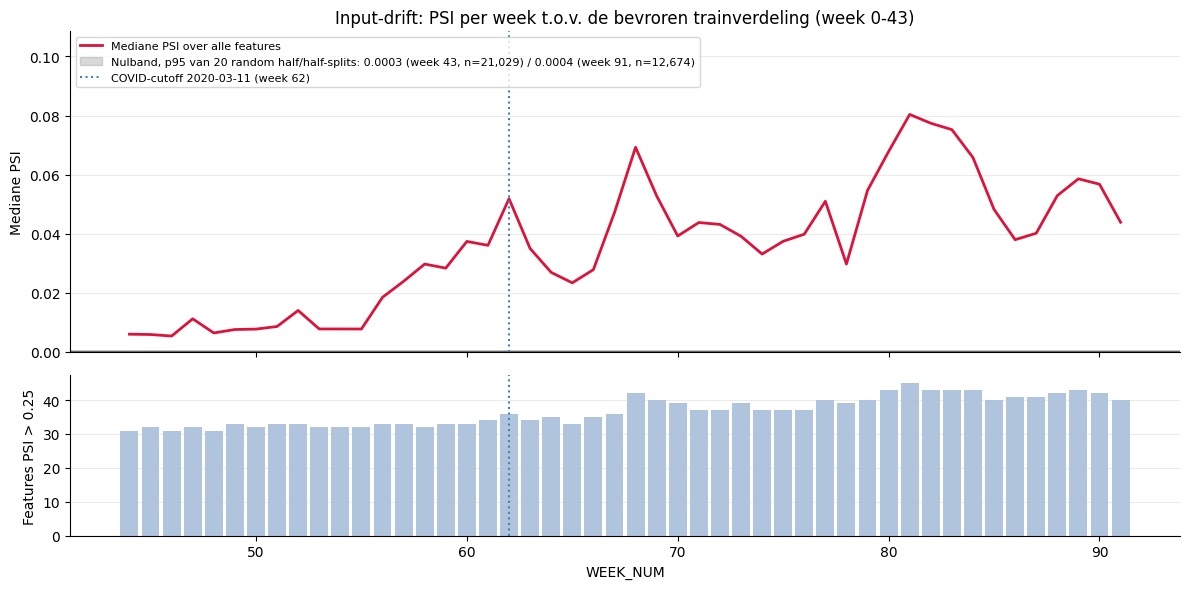

,week_num,median_psi,n_features_above_alert
0,44,0.006001,31
1,45,0.005894,32
2,46,0.005376,31
3,47,0.011207,32
4,48,0.006422,31
5,49,0.007584,33
6,50,0.007724,32
7,51,0.008605,33
8,52,0.014030,33
9,53,0.007771,32


In [9]:
noise_ceiling = max(null_thresholds.values())

fig, (ax_psi, ax_cnt) = plt.subplots(
    2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax_psi.plot(psi_summary["week_num"], psi_summary["median_psi"],
            color="crimson", linewidth=2, label="Mediane PSI over alle features")
ax_psi.axhspan(0, noise_ceiling, color="dimgray", alpha=0.25, label=(
    "Nulband, p95 van 20 random half/half-splits: "
    + " / ".join(f"{null_thresholds[w]:.4f} (week {w}, n={len(null_week_values[w]):,})"
                 for w in NULL_WEEKS)))
for week in NULL_WEEKS:
    ax_psi.axhline(null_thresholds[week], color="dimgray", linewidth=1)
ax_psi.axvline(COVID_WEEK, color="steelblue", linestyle=":", linewidth=1.5,
               label=f"COVID-cutoff {COVID_DATE.date()} (week {COVID_WEEK})")
ax_psi.set_ylabel("Mediane PSI")
ax_psi.set_ylim(0, psi_summary["median_psi"].max() * 1.35)  # ruimte voor de legende
ax_psi.set_title(f"Input-drift: PSI per week t.o.v. de bevroren trainverdeling "
                 f"(week 0-{LAST_TRAIN_WEEK})")
ax_psi.legend(loc="upper left", fontsize=8)

ax_cnt.bar(psi_summary["week_num"], psi_summary["n_features_above_alert"],
           color="lightsteelblue", width=0.85)
ax_cnt.axvline(COVID_WEEK, color="steelblue", linestyle=":", linewidth=1.5)
ax_cnt.set_ylabel(f"Features PSI > {PSI_ALERT}")
ax_cnt.set_xlabel("WEEK_NUM")

for ax in (ax_psi, ax_cnt):
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

psi_summary

In [10]:
# Welke features dragen de drift vanaf de COVID-cutoff?
top_drift = (
    psi_long[psi_long["week_num"] >= COVID_WEEK]
    .groupby("feature")["psi"].median()
    .sort_values(ascending=False)
    .head(15)
    .rename("median_psi_vanaf_covid")
    .reset_index()
)
top_drift

,feature,median_psi_vanaf_covid
0,responsedate_1012D_missing,9.402027
1,pmtscount_423L_missing,6.781217
2,description_5085714M,6.159579
3,birthdate_574D,5.248052
4,pmtssum_45A,5.174664
5,mode_employername_160M,4.533674
6,pmtscount_423L,3.628380
7,max_processingdate_168D,3.627278
8,numinstmatpaidtearly2d_4499204L,1.342051
9,assignmentdate_238D_missing,1.232110
